# GSE130973 — Skin Aging Re-analysis (Fibroblasts & Macrophages)

**Optimised pipeline.** Single notebook, organised into the three logical stages from the
methods memo:

1. **Preprocessing & Annotation** — ingest, QC, integrate (Harmony), Leiden + canonical-marker labels
2. **Pseudobulk Differential Expression** — donor-aware PyDESeq2 (Negative Binomial + Wald), **genome-wide**
3. **Systems Inference** — TF activity (decoupleR + **DoRothEA** + **ULM**) and cell–cell communication (LIANA **consensus** rank)

### What changed vs. the original notebook (and why)
- **TF inference now genuinely uses decoupleR + DoRothEA + ULM.** The old code fetched *CollecTRI*
  and ran a `scipy` 1-sample t-test, which is neither DoRothEA nor a univariate linear model.
- **DE is run on the full gene set, not the 3,000 HVGs.** The old code subset `adata` to HVGs
  *before* the counts layer was used, so DESeq2 only ever saw 3,000 genes. HVGs are now used
  **only** for the embedding; all genes are retained for testing.
- **LIANA significance now uses the consensus `specificity_rank`,** not a single method's
  `cellphone_pvals` — that is the whole point of `rank_aggregate`.
- **Versions are pinned** (notably `decoupler<2`) so the documented API is the one that runs.

## Stage 0 — Environment

In [1]:
# Pinned to keep the documented APIs stable.
# decoupler<2  -> exposes get_dorothea() + run_ulm() (the 2.x dc.op/dc.mt API differs).
!pip install -q \
    "scanpy" "anndata" "harmonypy" "scrublet" "leidenalg" "igraph" \
    "pydeseq2" "liana" "decoupler<2" "omnipath" "rpy2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 28.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.9/563.9 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=120, frameon=False)

os.makedirs("data/raw", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Scanpy", sc.__version__)

Scanpy 1.12.1


## Stage 1 — Preprocessing & Annotation

### 1a. Download raw data
We need the filtered count matrix (MTX triplet) and the author's Seurat object — the latter only
to recover the **ground-truth donor (`subj`) and age labels**, which are the backbone of the
donor-aware design.

In [3]:
import urllib.request

base = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE130nnn/GSE130973/suppl/"
mtx_files = {
    "matrix":   "GSE130973_matrix_filtered.mtx.gz",
    "barcodes": "GSE130973_barcodes_filtered.tsv.gz",
    "genes":    "GSE130973_genes_filtered.tsv.gz",
}
for _, fn in mtx_files.items():
    dst = f"data/raw/{fn}"
    if not os.path.exists(dst):
        print("Downloading", fn)
        urllib.request.urlretrieve(base + fn, dst)
print("Matrix components ready.")

%load_ext rpy2.ipython

Matrix components ready.


In [4]:
%%R
# Extract ONLY the metadata slot from the author's Seurat .rds (no Seurat install needed).
options(timeout = 1200)
rds_gz <- "data/raw/GSE130973_seurat_analysis_lyko.rds.gz"
rds    <- "data/raw/GSE130973_seurat_analysis_lyko.rds"
url    <- "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE130nnn/GSE130973/suppl/GSE130973_seurat_analysis_lyko.rds.gz"

if (!file.exists(rds_gz) && !file.exists(rds)) {
    cat("Downloading author Seurat object (~441 MB)...\n")
    download.file(url, rds_gz)
}
if (!file.exists(rds)) system(paste("gunzip -f", rds_gz))

obj  <- readRDS(rds)
meta <- slot(obj, "meta.data")
write.csv(meta, "data/raw/ground_truth_metadata.csv")
cat("Metadata extracted:", nrow(meta), "cells x", ncol(meta), "fields\n")

Metadata extracted: 15457 cells x 8 fields


trying URL 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE130nnn/GSE130973/suppl/GSE130973_seurat_analysis_lyko.rds.gz'
Content type 'application/x-gzip' length 462376986 bytes (441.0 MB)
downloaded 441.0 MB



### 1b. Ingest matrix and attach ground-truth labels
The matrix's `orig.ident` is a leftover project tag (`10X_PBMC`), **not** the donor. The real
biological replicate is the `subj` column (S1–S5). We standardise three pipeline variables here:
`donor` (= `subj`), `age` (YOUNG/OLD), and `batch` (= donor, for Harmony).

In [5]:
print("Reading MTX...")
adata = sc.read_mtx("data/raw/GSE130973_matrix_filtered.mtx.gz").T
barcodes = pd.read_csv("data/raw/GSE130973_barcodes_filtered.tsv.gz", header=None, sep="\t")[0].values
genes    = pd.read_csv("data/raw/GSE130973_genes_filtered.tsv.gz",    header=None, sep="\t")
adata.obs_names = barcodes
adata.var_names = (genes[1] if genes.shape[1] >= 2 else genes[0]).values
adata.var_names_make_unique()

meta = pd.read_csv("data/raw/ground_truth_metadata.csv", index_col=0)

# Align by barcode; fall back to the raw ATCG sequence if suffixes were edited.
common = adata.obs_names.intersection(meta.index)
if len(common) > 0:
    adata = adata[common].copy()
    adata.obs = adata.obs.join(meta)
else:
    print("Exact barcode match failed; aligning on raw sequence.")
    adata.obs["_bc"] = adata.obs_names.str.split("-").str[0].str.split("_").str[0]
    meta["_bc"] = meta.index.str.split("-").str[0].str.split("_").str[0]
    m = meta.drop_duplicates("_bc").set_index("_bc")
    for c in [c for c in meta.columns if c != "_bc"]:
        adata.obs[c] = adata.obs["_bc"].map(m[c])

# Standardise pipeline variables
adata.obs["donor"] = adata.obs["subj"].astype("category")
adata.obs["age"]   = adata.obs["age"].astype(str).str.upper().astype("category")
adata.obs["batch"] = adata.obs["donor"]

print(f"{adata.n_obs} cells x {adata.n_vars} genes")
print("\nDonors:\n", adata.obs["donor"].value_counts())
print("\nAge:\n", adata.obs["age"].value_counts())
print(f"\nDistinct donors: {adata.obs['donor'].nunique()}")

Reading MTX...
15457 cells x 32738 genes

Donors:
 donor
S5    4535
S3    3324
S1    2784
S2    2670
S4    2144
Name: count, dtype: int64

Age:
 age
OLD      10003
YOUNG     5454
Name: count, dtype: int64

Distinct donors: 5


### 1c. Quality control
Mitochondrial/ribosomal fractions, per-donor Scrublet doublet detection, then filtering. The raw
integer counts are saved to a **layer before any normalisation or gene subsetting** so the full
transcriptome is available for DESeq2 later.

In [6]:
import scrublet as scr

print("Cells before QC:", adata.n_obs)
adata.var["mt"]   = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True)

# Per-donor doublet detection
adata.obs["doublet_score"], adata.obs["predicted_doublet"] = 0.0, False
for d in adata.obs["donor"].cat.categories:
    sub = adata[adata.obs["donor"] == d].copy()
    if sub.n_obs > 50:
        s, p = scr.Scrublet(sub.X).scrub_doublets()
        adata.obs.loc[sub.obs_names, "doublet_score"] = s
        adata.obs.loc[sub.obs_names, "predicted_doublet"] = p
print("Predicted doublets:", int(adata.obs["predicted_doublet"].sum()))

# Filtering (gene-level filter here is light; the strict count filter is applied at pseudobulk).
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 10].copy()
adata = adata[~adata.obs["predicted_doublet"]].copy()

# *** Keep raw integer counts for the WHOLE gene set ***
adata.layers["counts"] = adata.X.copy()
print("Cells after QC:", adata.n_obs, "| genes retained:", adata.n_vars)

Cells before QC: 15457
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.64
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 10.0%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.0%
Elapsed time: 3.6 seconds
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.47
Detected doublet rate = 0.8%
Estimated detectable doublet fraction = 23.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.4%
Elapsed time: 3.3 seconds
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.40
Detected doublet rate = 1.4%
Estimated detectable doublet fraction = 42.0%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.4%
Elapsed time: 4.2 seconds
Preprocessi

### 1d. Normalise, integrate (Harmony), cluster

**Key fix:** we do **not** subset `adata` to HVGs. PCA uses the HVG mask automatically
(`use_highly_variable=True`), so the embedding is driven by HVGs while `adata` keeps **all genes**
for differential expression. Scaling is done on a throwaway copy used only for PCA, leaving `.X`
as log-normalised values for scoring, dotplots, and LIANA.

2026-06-13 06:38:37,828 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-06-13 06:38:37,829 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-06-13 06:38:37,830 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-06-13 06:38:37,832 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-06-13 06:38:37,834 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-06-13 06:38:37,835 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-06-13 06:38:37,837 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-06-13 06:38:37,837 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-06-13 06:38:37,839 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-06-13 06:38:37,840 - harmonypy - INFO -     theta: [2. 2. 2

Harmony embedding stored: (14696, 50)


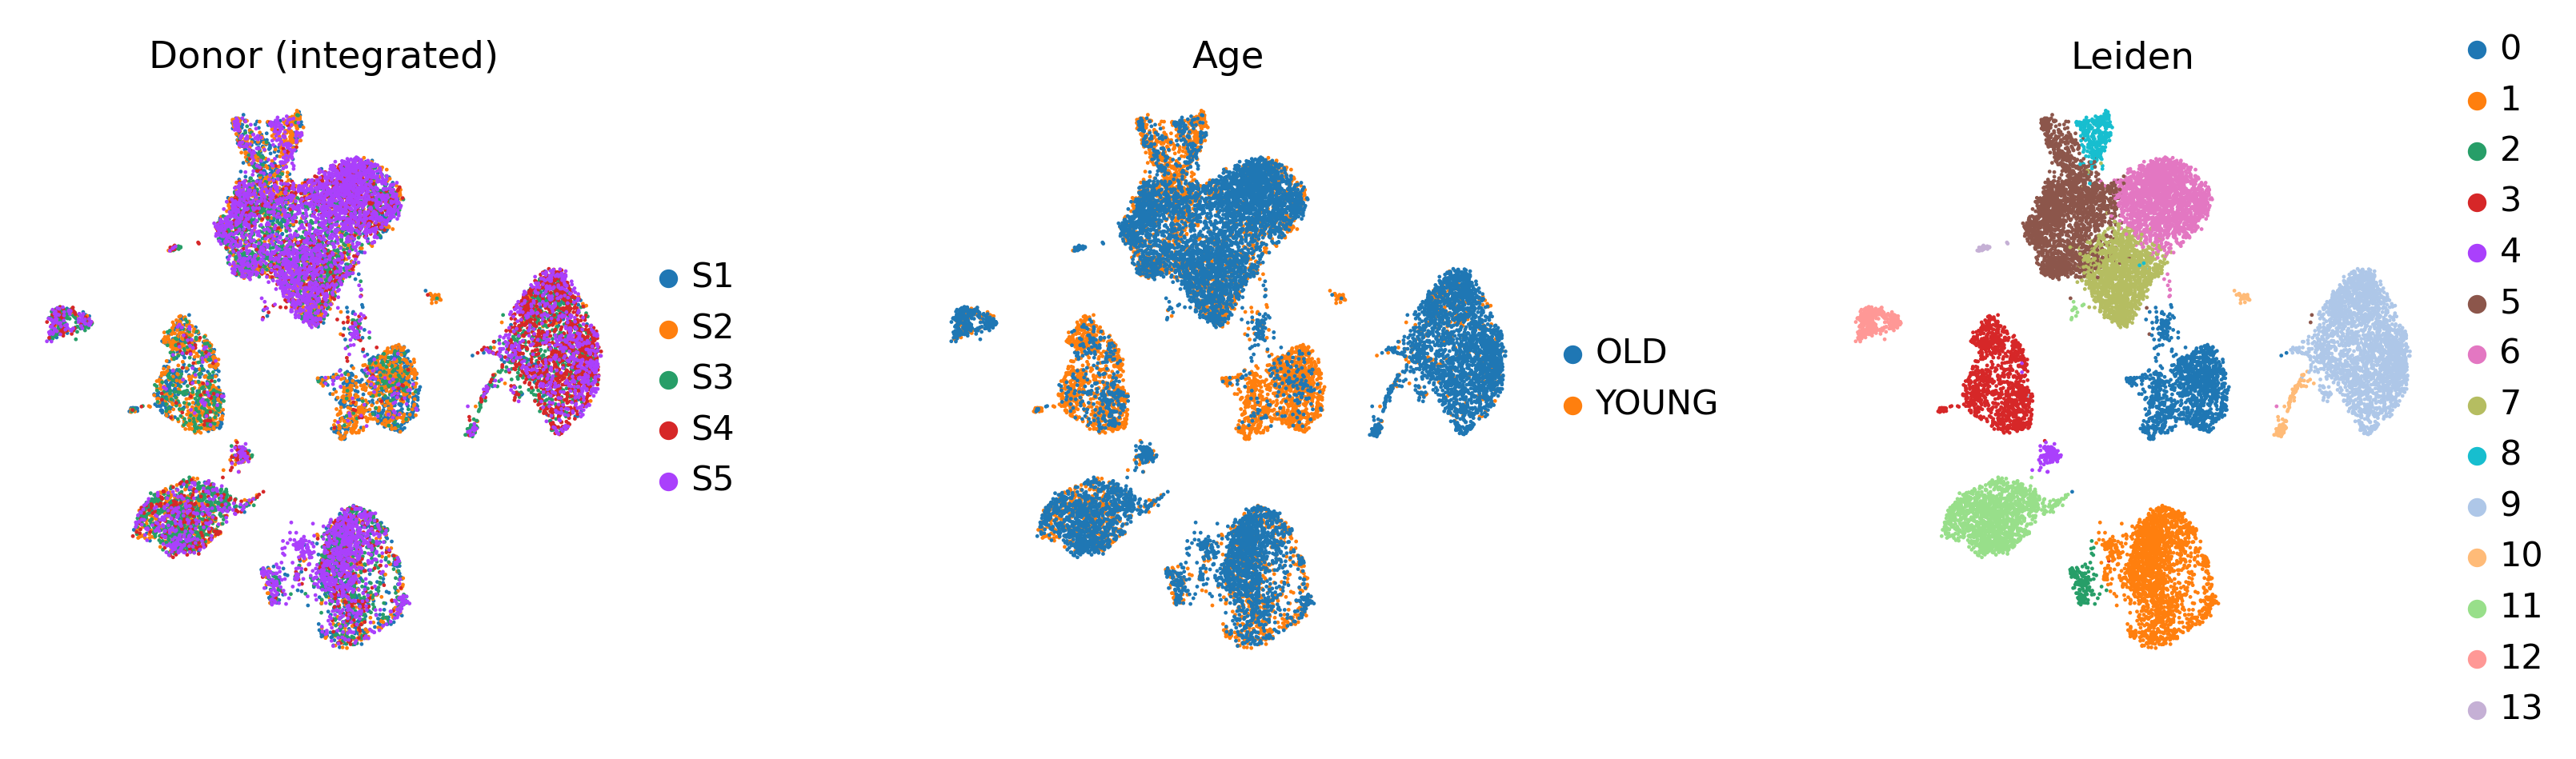

In [8]:
import harmonypy

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()          # keep log-norm for downstream

sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat")

# PCA on a scaled COPY restricted to HVGs (adata itself stays full + log-norm).
scaled = adata[:, adata.var["highly_variable"]].copy()
sc.pp.scale(scaled, max_value=10)
sc.tl.pca(scaled, n_comps=50, svd_solver="arpack", random_state=RANDOM_SEED)
adata.obsm["X_pca"] = scaled.obsm["X_pca"]
del scaled

# Harmony batch correction across donors — call harmonypy directly and assign
# the corrected embedding ourselves. The sc.external wrapper is sensitive to
# harmonypy version drift and can return a wrongly-shaped Z_corr.
ho = harmonypy.run_harmony(adata.obsm["X_pca"], adata.obs, ["donor"],
                           random_state=RANDOM_SEED)

Z = np.asarray(ho.Z_corr)                          # numpy.matrix -> ndarray
if Z.shape[0] == adata.n_obs:                      # already (cells x PCs)
    Z_cells = Z
elif Z.shape[1] == adata.n_obs:                    # (PCs x cells) -> transpose
    Z_cells = Z.T
else:
    raise ValueError(f"Harmony returned {Z.shape}, matches neither "
                     f"cells ({adata.n_obs}) nor PCs.")
adata.obsm["X_pca_harmony"] = np.ascontiguousarray(Z_cells)
print("Harmony embedding stored:", adata.obsm["X_pca_harmony"].shape)

sc.pp.neighbors(adata, n_pcs=30, use_rep="X_pca_harmony", random_state=RANDOM_SEED)
sc.tl.umap(adata, random_state=RANDOM_SEED)
sc.tl.leiden(adata, resolution=0.4, random_state=RANDOM_SEED,
             flavor="igraph", n_iterations=2, directed=False)

sc.pl.umap(adata, color=["donor", "age", "leiden"], wspace=0.35,
           title=["Donor (integrated)", "Age", "Leiden"])

### 1e. Annotate clusters (canonical markers) and verify with a dotplot
Each Leiden cluster is labelled by the marker signature with the highest mean score; the dotplot
is the visual proof that `DCN`/`LUM` mark the fibroblast cluster and `LYZ`/`CD68` the macrophages.

cell_type
Fibroblasts      5811
Keratinocytes    2487
Macrophages      2137
Endothelial      1739
T_Cells          1295
Unknown          1075
Melanocytes       152
Name: count, dtype: int64


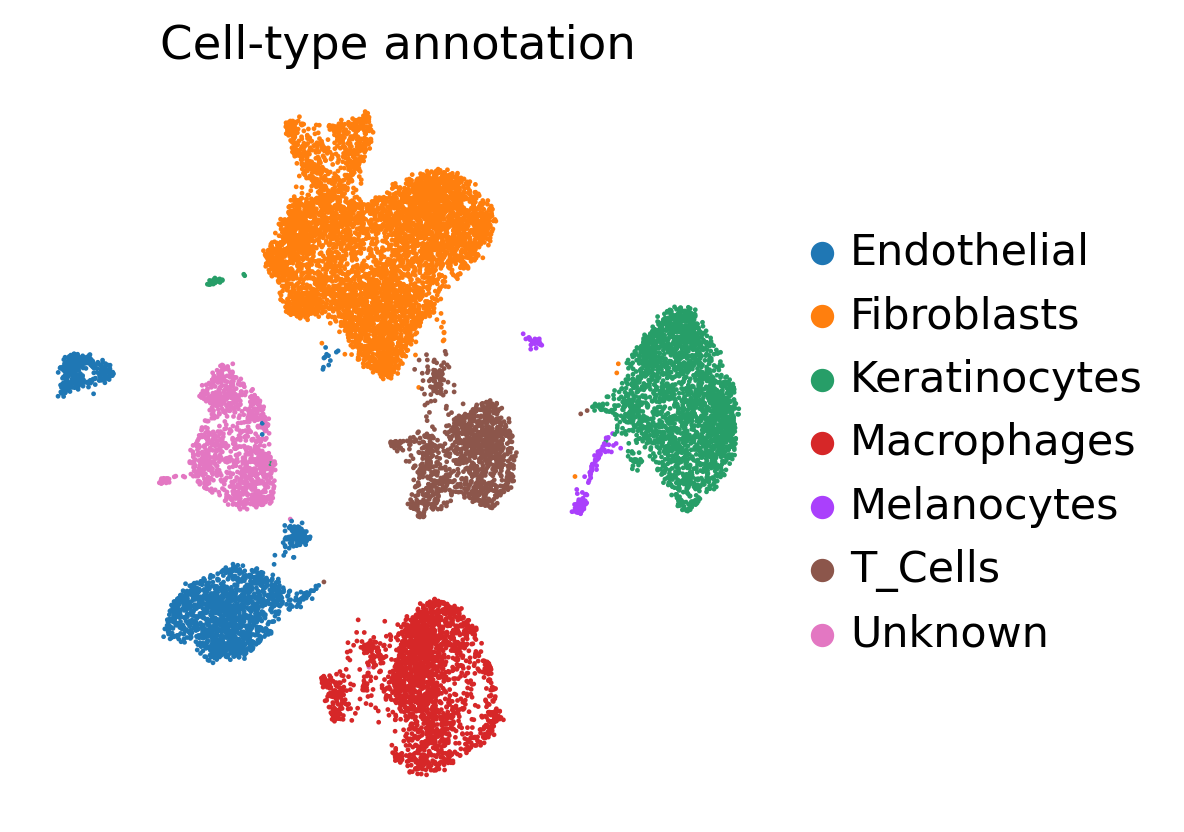

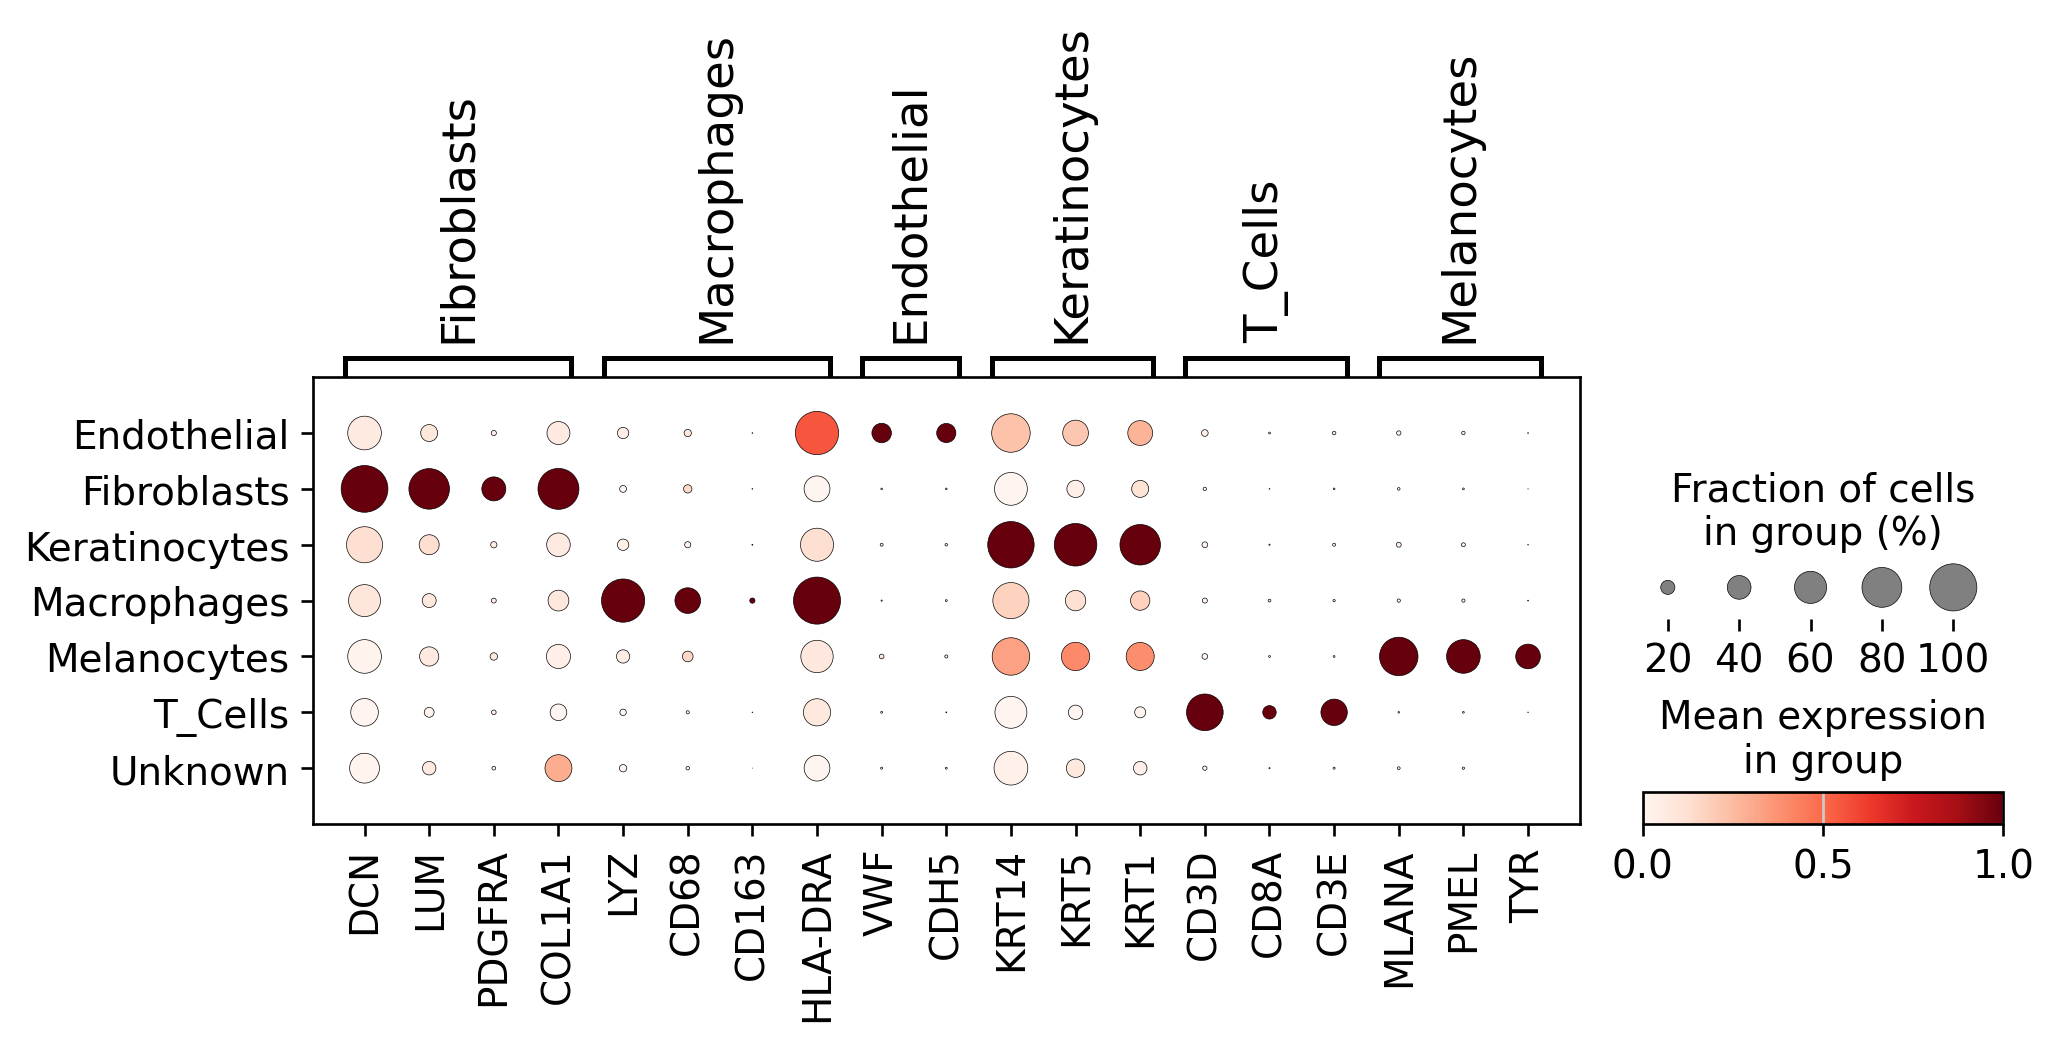

In [9]:
markers = {
    "Fibroblasts":   ["DCN", "LUM", "PDGFRA", "COL1A1"],
    "Macrophages":   ["LYZ", "CD68", "CD163", "HLA-DRA"],
    "Endothelial":   ["PECAM1", "VWF", "CDH5"],
    "Keratinocytes": ["KRT14", "KRT5", "KRT1"],
    "T_Cells":       ["CD3D", "CD8A", "CD3E"],
    "Melanocytes":   ["MLANA", "PMEL", "TYR"],
}

adata.X = adata.layers["lognorm"].copy()           # score on log-norm, not scaled data
score_cols = []
for ct, gs in markers.items():
    g = [x for x in gs if x in adata.var_names]
    if g:
        sc.tl.score_genes(adata, g, score_name=f"{ct}_score")
        score_cols.append(f"{ct}_score")

cluster_scores = adata.obs.groupby("leiden", observed=True)[score_cols].mean()
mapping = {}
for cl in cluster_scores.index:
    best = cluster_scores.loc[cl].idxmax()
    mapping[cl] = best.replace("_score", "") if cluster_scores.loc[cl, best] > 0.05 else "Unknown"
adata.obs["cell_type"] = adata.obs["leiden"].map(mapping).astype("category")

print(adata.obs["cell_type"].value_counts())
sc.pl.umap(adata, color="cell_type", title="Cell-type annotation")
present = {k: [m for m in v if m in adata.var_names] for k, v in markers.items()}
sc.pl.dotplot(adata, present, groupby="cell_type", standard_scale="var")

## Stage 2 — Pseudobulk Differential Expression (Fibroblasts, genome-wide)

We collapse fibroblasts to one pseudobulk profile **per donor** by summing raw counts, then run
PyDESeq2 (Negative Binomial + Wald) on the `OLD vs YOUNG` contrast. With N=5 donors this respects
biological replication and avoids pseudoreplication.

Two deliberate choices:
- **Sparse aggregation** via an indicator-matrix product — fast and memory-safe on the full
  ~25k-gene matrix (no dense 5,860×25,000 intermediate).
- **Filter weak genes at the pseudobulk level** (total ≥ 10 counts across donors) instead of using
  HVGs. This is the correct place to reduce the multiple-testing burden without biasing which genes
  are testable.

In [10]:
fibro = adata[adata.obs["cell_type"] == "Fibroblasts"].copy()
print("Fibroblasts:", fibro.n_obs)

def pseudobulk(ad, sample_col="donor", layer="counts"):
    X = ad.layers[layer]
    X = X.tocsr() if sp.issparse(X) else sp.csr_matrix(X)
    s = ad.obs[sample_col].astype(str).values
    cats = pd.unique(s)
    row = {c: i for i, c in enumerate(cats)}
    idx = np.fromiter((row[v] for v in s), dtype=int, count=len(s))
    ind = sp.csr_matrix((np.ones(len(s)), (idx, np.arange(len(s)))), shape=(len(cats), X.shape[0]))
    pb = np.asarray(ind.dot(X).todense())
    counts = pd.DataFrame(pb, index=cats, columns=ad.var_names).round().astype(int)
    cond = ad.obs.groupby(sample_col, observed=True)["age"].first().astype(str)
    metad = pd.DataFrame({"condition": cond.loc[cats].values}, index=cats)
    return counts, metad

pb_counts, pb_meta = pseudobulk(fibro)
pb_counts = pb_counts.loc[:, pb_counts.sum(0) >= 10]      # drop near-zero genes
pb_meta["condition"] = pd.Categorical(pb_meta["condition"], categories=["YOUNG", "OLD"])
print("Pseudobulk:", pb_counts.shape, "\n", pb_meta)

Fibroblasts: 5811
Pseudobulk: (5, 15190) 
    condition
S1     YOUNG
S2     YOUNG
S3       OLD
S4       OLD
S5       OLD


In [11]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds = DeseqDataSet(counts=pb_counts, metadata=pb_meta, design="~condition", quiet=True)
dds.deseq2()

stat_res = DeseqStats(dds, contrast=["condition", "OLD", "YOUNG"], quiet=True)
stat_res.summary()
res_df = stat_res.results_df.dropna(subset=["padj"]).copy()

sig = res_df[(res_df["padj"] < 0.05) & (res_df["log2FoldChange"].abs() > 0.58)] \
        .sort_values("log2FoldChange", ascending=False)
print(f"\nGenome-wide significant DEGs (FDR<0.05, |LFC|>0.58): {len(sig)}")

res_df.to_csv("results/Fibroblasts_Old_vs_Young_DESeq2_Full.csv")
sig.to_csv("results/Fibroblasts_Old_vs_Young_Significant.csv")

# Sanity check on the manuscript anchor genes
for g in ["COCH", "DEFB1"]:
    if g in res_df.index:
        r = res_df.loc[g]
        print(f"{g}: log2FC={r['log2FoldChange']:.2f}, padj={r['padj']:.2e}")
display(sig.head(8)[["log2FoldChange", "padj"]])
display(sig.tail(8)[["log2FoldChange", "padj"]])


Genome-wide significant DEGs (FDR<0.05, |LFC|>0.58): 200
COCH: log2FC=-4.20, padj=8.36e-04
DEFB1: log2FC=3.92, padj=2.96e-04


,log2FoldChange,padj
IGJ,5.194117,0.010213
TMEM40,4.641487,0.014392
LAD1,4.297471,0.046794
MPZL2,4.076397,0.000019
DEFB1,3.924309,0.000296
MAL2,3.801333,0.000563
DMKN,3.313001,0.043263
RNF144B,3.189835,0.047193


,log2FoldChange,padj
UGT3A2,-3.039639,0.041422
TNN,-3.093521,0.000012
ZC2HC1C,-3.150211,0.032104
TNMD,-3.163512,0.000001
TAC1,-3.199062,0.002997
MYOC,-3.475147,0.000162
DCX,-3.598955,0.004924
COCH,-4.202022,0.000836


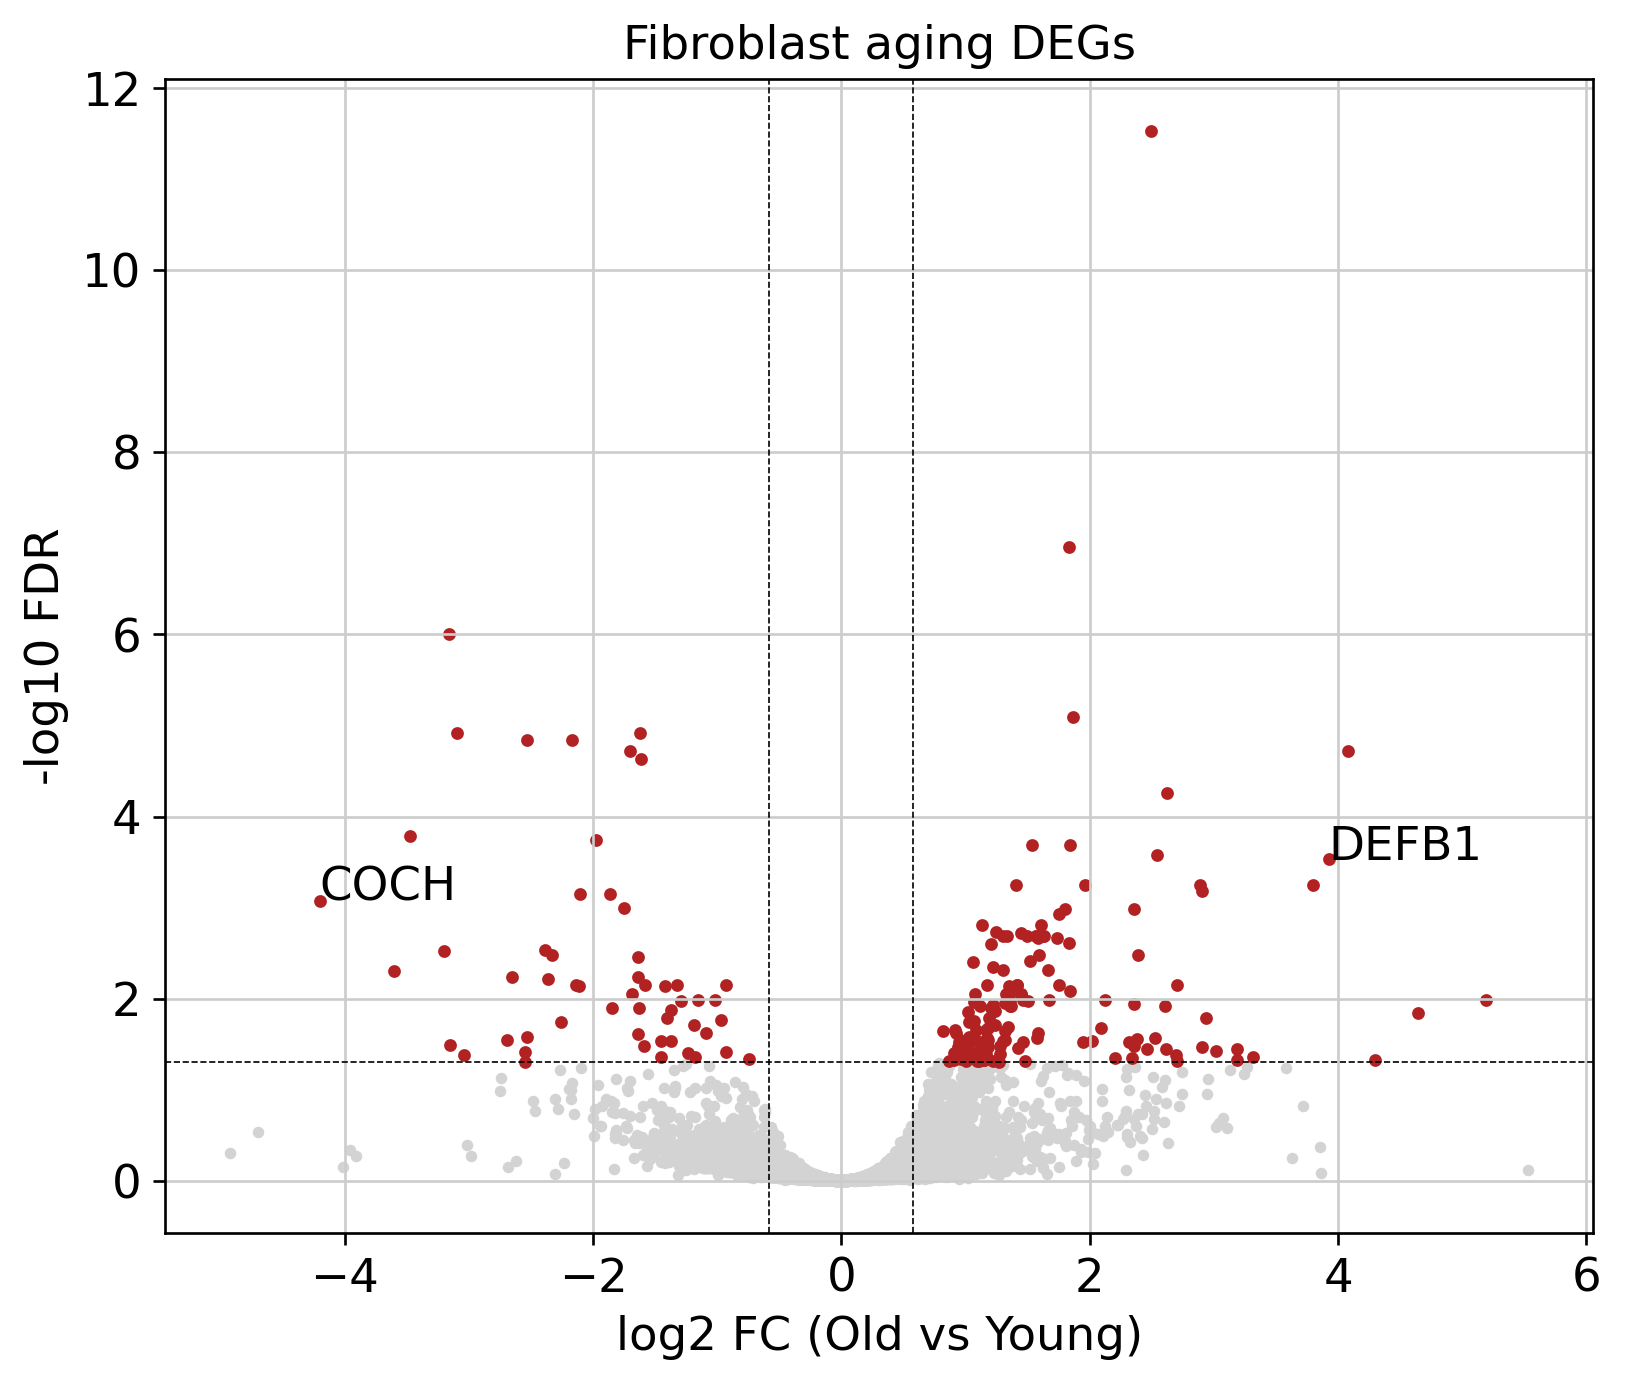

In [12]:
# Volcano
d = res_df.copy()
d["-log10padj"] = -np.log10(d["padj"].clip(lower=1e-300))
d["sig"] = (d["padj"] < 0.05) & (d["log2FoldChange"].abs() > 0.58)
plt.figure(figsize=(7, 6))
plt.scatter(d.loc[~d.sig, "log2FoldChange"], d.loc[~d.sig, "-log10padj"], s=6, c="lightgray")
plt.scatter(d.loc[d.sig, "log2FoldChange"],  d.loc[d.sig, "-log10padj"],  s=8, c="firebrick")
for g in ["COCH", "DEFB1"]:
    if g in d.index:
        plt.annotate(g, (d.loc[g, "log2FoldChange"], d.loc[g, "-log10padj"]))
plt.axvline(0.58, ls="--", c="k", lw=.5); plt.axvline(-0.58, ls="--", c="k", lw=.5)
plt.axhline(-np.log10(0.05), ls="--", c="k", lw=.5)
plt.xlabel("log2 FC (Old vs Young)"); plt.ylabel("-log10 FDR"); plt.title("Fibroblast aging DEGs")
plt.tight_layout(); plt.savefig("figures/volcano.pdf"); plt.show()

## Stage 3a — Transcription-factor activity (decoupleR + DoRothEA + ULM)

This is the corrected systems-inference step. We feed the **DESeq2 Wald statistic** for every gene
into a **univariate linear model** against the **DoRothEA** regulon (confidence levels A/B/C). The
ULM activity score reflects whether a TF's targets move coherently — the proper "footprint" logic,
not the TF's own mRNA level.

In [14]:
# decoupler's GSVA module JIT-compiles an np.arange() call that newer numba
# rejects. We never use GSVA (only ULM, which is pure-numpy), so disable JIT
# *before* importing decoupler: the offending function is left uncompiled and
# never runs. Must be set before the import to affect decoupler's @njit funcs.
import numba
numba.config.DISABLE_JIT = True

import decoupler as dc

# DoRothEA, high-confidence regulons only
dorothea = dc.get_dorothea(organism="human", levels=["A", "B", "C"])
print("DoRothEA edges:", len(dorothea), "| TFs:", dorothea["source"].nunique())

# One-row matrix of Wald stats (sample = the contrast), genes as columns
mat = res_df[["stat"]].dropna().T
mat.index = ["Old_vs_Young"]

estimate, pvals = dc.run_ulm(mat=mat, net=dorothea,
                             source="source", target="target", weight="weight", min_n=5)

tf = (pd.DataFrame({"activity": estimate.loc["Old_vs_Young"],
                    "p_value":  pvals.loc["Old_vs_Young"]})
        .dropna().sort_values("activity", ascending=False))
tf.to_csv("results/DoRothEA_TF_Activity_Scores.csv")

print("\nIndexing exactly as the methods memo's traceability matrix:")
for g in ["SRF", "CIITA"]:
    if g in estimate.columns:
        print(f"  estimate.loc['Old_vs_Young','{g}'] = {estimate.loc['Old_vs_Young', g]:.2f} "
              f"(ULM p = {pvals.loc['Old_vs_Young', g]:.3f})")

sig_tf = tf[tf["p_value"] < 0.05]
print(f"\nSignificant TFs (p<0.05): {len(sig_tf)}")
display(sig_tf.head(8)); display(sig_tf.tail(8))

0.00B [00:00, ?B/s]

DoRothEA edges: 32286 | TFs: 429

Indexing exactly as the methods memo's traceability matrix:
  estimate.loc['Old_vs_Young','SRF'] = 2.23 (ULM p = 0.026)

Significant TFs (p<0.05): 129


,activity,p_value
FOXA1,9.181634,5.000434e-20
GATA3,8.072860,7.577973e-16
GATA2,8.041854,9.750602e-16
FOS,7.725493,1.210482e-14
TAL1,6.907710,5.195727e-12
SPI1,6.756664,1.482968e-11
CEBPA,6.369740,1.968627e-10
TEAD1,6.152252,7.903141e-10


,activity,p_value
STAT2,-1.967919,0.049102
YBX1,-2.001116,0.045404
MAZ,-2.027445,0.042641
SNAPC4,-2.137855,0.032550
ZBTB7A,-2.456080,0.014061
THAP1,-2.524796,0.011590
GLI2,-2.704367,0.006854
MBD1,-2.978897,0.002899


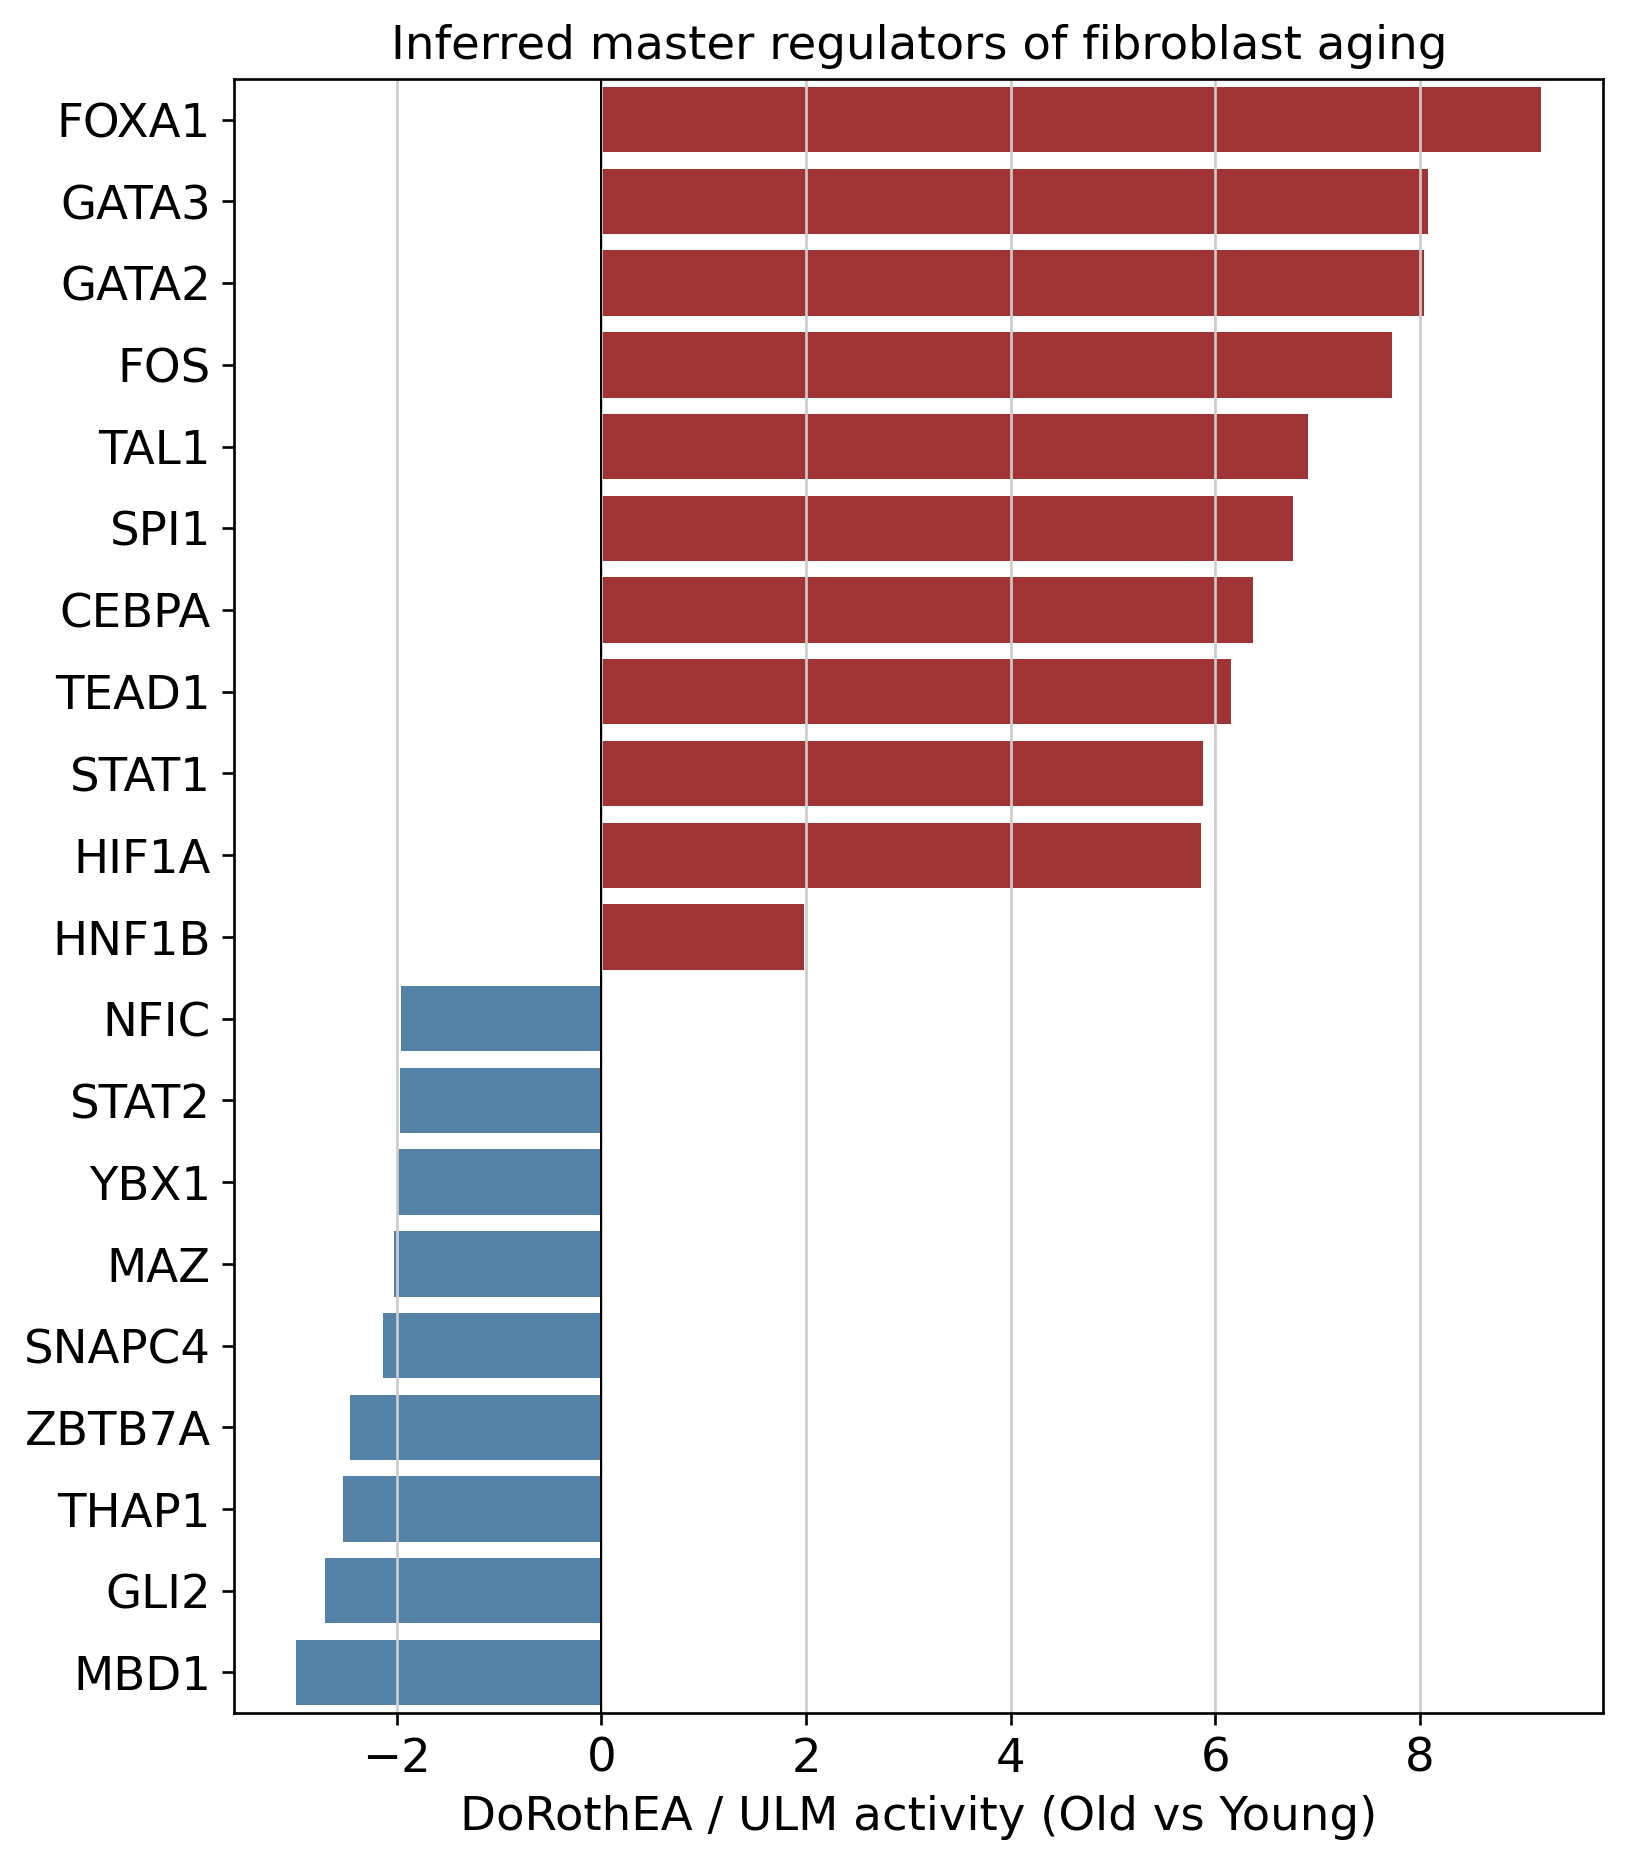

In [15]:
top = pd.concat([sig_tf.head(10), sig_tf.tail(10)])
plt.figure(figsize=(7, 8))
sns.barplot(data=top.reset_index(), x="activity", y="index",
            palette=["firebrick" if v > 0 else "steelblue" for v in top["activity"]])
plt.axvline(0, c="k", lw=.6)
plt.xlabel("DoRothEA / ULM activity (Old vs Young)"); plt.ylabel("")
plt.title("Inferred master regulators of fibroblast aging")
plt.tight_layout(); plt.savefig("figures/TF_activity.pdf"); plt.show()

## Stage 3b — Cell–cell communication (LIANA consensus)

`rank_aggregate` runs several methods (CellPhoneDB, NATMI, Connectome, …) and returns a
**consensus** `specificity_rank` (interpretable as a p-value via Robust Rank Aggregation). We run it
separately on young and old fibroblast→macrophage signalling and filter on that consensus rank —
**not** a single method's p-value — then take the set difference for emergent vs. lost axes.

In [16]:
import liana as li

cc = adata[adata.obs["cell_type"].isin(["Fibroblasts", "Macrophages"])].copy()
cc.X = cc.layers["lognorm"].copy()          # LIANA expects log-norm, non-negative

def f2m_consensus(ad_age, thr=0.05):
    li.mt.rank_aggregate(ad_age, groupby="cell_type", use_raw=False,
                         return_all_lrs=False, verbose=False)
    r = ad_age.uns["liana_res"]
    r = r[(r["source"] == "Fibroblasts") & (r["target"] == "Macrophages")].copy()
    r = r[r["specificity_rank"] < thr]                     # CONSENSUS, not cellphone_pvals
    r["interaction"] = r["ligand_complex"] + " -> " + r["receptor_complex"]
    return r

y = f2m_consensus(cc[cc.obs["age"] == "YOUNG"].copy())
o = f2m_consensus(cc[cc.obs["age"] == "OLD"].copy())
print(f"Young axes: {len(y)} | Old axes: {len(o)}")

emergent = sorted(set(o["interaction"]) - set(y["interaction"]))
lost     = sorted(set(y["interaction"]) - set(o["interaction"]))

pd.DataFrame({"interaction": emergent, "status": "emergent"}) \
  .to_csv("results/LIANA_Emergent_and_Lost_Axes.csv", index=False)
o.to_csv("results/Aged_Fibroblast_to_Macrophage_Crosstalk.csv", index=False)

print("\nEmergent in aged skin:")
for i in emergent[:15]: print("  +", i, "  <-- CCL21->CCR7 expected here" if i == "CCL21 -> CCR7" else "")
print("\nLost in aged skin:")
for i in lost[:15]: print("  -", i)

Young axes: 21 | Old axes: 10

Emergent in aged skin:
  + CCL19 -> CCR7 
  + FN1 -> PLAUR 
  + HEBP1 -> FPR3 

Lost in aged skin:
  - ANGPTL1 -> LILRB2
  - C3 -> ITGAX
  - CFH -> ITGAM
  - COL1A1 -> CD36
  - COL1A1 -> CD93
  - COL1A2 -> CD36
  - COL1A2 -> CD93
  - CXCL12 -> CD4
  - F10 -> ITGAM
  - SLPI -> CD4
  - THBS2 -> CD36
  - THY1 -> ITGAM_ITGB2
  - THY1 -> ITGAX_ITGB2
  - VCAN -> TLR2


## Save annotated object

In [17]:
adata.X = adata.layers["lognorm"].copy()
adata.write("results/annotated_fibro_macro_GSE130973.h5ad")
print("Saved results/annotated_fibro_macro_GSE130973.h5ad")
print("Outputs:", os.listdir("results"))

Saved results/annotated_fibro_macro_GSE130973.h5ad
Outputs: ['Fibroblasts_Old_vs_Young_DESeq2_Full.csv', 'Fibroblasts_Old_vs_Young_Significant.csv', 'DoRothEA_TF_Activity_Scores.csv', 'LIANA_Emergent_and_Lost_Axes.csv', 'Aged_Fibroblast_to_Macrophage_Crosstalk.csv', 'annotated_fibro_macro_GSE130973.h5ad']
